<a href="https://colab.research.google.com/github/92kunheekim/tcrpmhc_pose_binding/blob/main/notebooks/pretrain_tcr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pretrain TCR chain encoders on the gathered corpus

Self-supervised per-chain **autoencoder** warm-start (Vα, Vβ, CDR3α, CDR3β) on the
deduplicated multi-database corpus in `data/tcr_pretraining/tcr_pretrain_corpus.csv`
(~177k unique chains). Reconstruction is dominated by the germline scaffold; this is a
**warm-start / regularizer**, not a specificity learner.

Clones the repo into `/content`, writes outputs into the repo, then commits & pushes.
Run on Colab (GPU).

## Clone repo
Add your token in Colab **Secrets** (🔑 left sidebar) as `GITHUB_TOKEN`, then run.

In [13]:
import os, sys, subprocess
REPO = '/content/tcrpmhc_pose_binding'
REPO_URL = 'github.com/92kunheekim/tcrpmhc_pose_binding.git'
from google.colab import userdata
TOKEN = userdata.get('GITHUB_TOKEN')
if not os.path.isdir(REPO):
    subprocess.run(['git', 'clone', f'https://x-access-token:{TOKEN}@{REPO_URL}', REPO], check=True)
else:
    subprocess.run(['git', '-C', REPO, 'pull', '--ff-only'], check=True)   # refresh existing clone to latest main
os.chdir(REPO)
sys.path.insert(0, f'{REPO}/src')
DATA_DIR = f'{REPO}/data'
PRETRAIN_DIR = f'{REPO}/pretrained'; os.makedirs(PRETRAIN_DIR, exist_ok=True)
CORPUS = f'{DATA_DIR}/tcr_pretraining/tcr_pretrain_corpus.csv'
print('repo:', os.path.isdir(REPO), '| corpus:', os.path.isfile(CORPUS), '| out:', PRETRAIN_DIR)


repo: True | corpus: True | out: /content/tcrpmhc_pose_binding/pretrained


In [14]:
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', f'{REPO}/requirements.txt'])
import pandas as pd, torch, matplotlib.pyplot as plt
from train_utils import pretrain_tcr_encoders, DEVICE
print('device:', DEVICE)

device: cuda


## Config

In [15]:
TCR_EPOCHS = 1000    # upper bound; plateau early-stop usually ends sooner
PATIENCE   = 10
BATCH      = 256

## 1. Load corpus

Columns `va, vb, cdr3a, cdr3b` are independently deduplicated and `""`-padded —
`pretrain_tcr_encoders` drops the empty/padding entries per chain automatically.

In [16]:
seq = pd.read_csv(CORPUS).fillna('')
print('rows:', len(seq))
print('non-empty per chain:', {c: int(seq[c].astype(str).str.strip().ne('').sum()) for c in ['va','vb','cdr3a','cdr3b']})

rows: 117260
non-empty per chain: {'va': 1011, 'vb': 504, 'cdr3a': 58227, 'cdr3b': 117260}


## 2. Pretrain the four chain autoencoders

In [17]:
TCR_ENC, TCR_HIST = pretrain_tcr_encoders(
    seq, epochs=TCR_EPOCHS, bs=BATCH, patience=PATIENCE, return_history=True, log=True)
torch.save(TCR_ENC, f'{PRETRAIN_DIR}/tcr_encoders_corpus.pt')
pd.concat(TCR_HIST.values()).to_csv(f'{PRETRAIN_DIR}/tcr_encoder_corpus_history.csv', index=False)
print('saved -> tcr_encoders_corpus.pt')

  [va   ] ep  1 mse=2.1908 aa_acc=0.025 active=3/64
  [va   ] ep  5 mse=1.9286 aa_acc=0.077 active=64/64
  [va   ] ep 10 mse=1.6931 aa_acc=0.192 active=64/64
  [va   ] ep 15 mse=1.5281 aa_acc=0.262 active=64/64
  [va   ] ep 20 mse=1.3533 aa_acc=0.325 active=64/64
  [va   ] ep 25 mse=1.2044 aa_acc=0.389 active=64/64
  [va   ] ep 30 mse=1.0975 aa_acc=0.436 active=64/64
  [va   ] ep 35 mse=1.0096 aa_acc=0.476 active=64/64
  [va   ] ep 40 mse=0.9371 aa_acc=0.513 active=64/64
  [va   ] ep 45 mse=0.8775 aa_acc=0.543 active=64/64
  [va   ] ep 50 mse=0.8286 aa_acc=0.565 active=64/64
  [va   ] ep 55 mse=0.7891 aa_acc=0.583 active=64/64
  [va   ] ep 60 mse=0.7521 aa_acc=0.602 active=64/64
  [va   ] ep 65 mse=0.7199 aa_acc=0.617 active=64/64
  [va   ] ep 70 mse=0.6931 aa_acc=0.632 active=64/64
  [va   ] ep 75 mse=0.6713 aa_acc=0.643 active=64/64
  [va   ] ep 80 mse=0.6464 aa_acc=0.655 active=64/64
  [va   ] ep 85 mse=0.6226 aa_acc=0.668 active=64/64
  [va   ] ep 90 mse=0.6060 aa_acc=0.678 active=

## 3. Diagnostics: reconstruction MSE, amino-acid accuracy, active embedding dims

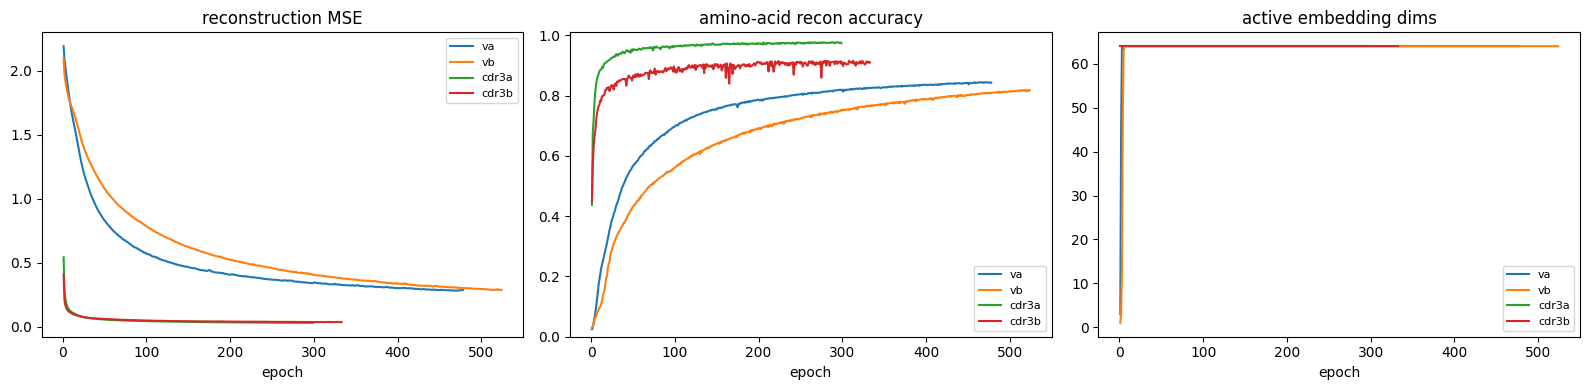

va   : final mse=0.2856  aa_acc=0.843  active=64/64
vb   : final mse=0.2861  aa_acc=0.818  active=64/64
cdr3a: final mse=0.0296  aa_acc=0.974  active=64/64
cdr3b: final mse=0.0352  aa_acc=0.911  active=64/64


In [18]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for ch, h in TCR_HIST.items():
    ax[0].plot(h.epoch, h.mse, label=ch)
    ax[1].plot(h.epoch, h.aa_acc, label=ch)
    ax[2].plot(h.epoch, h.active_emb, label=ch)
ax[0].set(title='reconstruction MSE', xlabel='epoch')
ax[1].set(title='amino-acid recon accuracy', xlabel='epoch', ylim=(0, 1.01))
ax[2].set(title='active embedding dims', xlabel='epoch')
for a in ax:
  a.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{PRETRAIN_DIR}/tcr_encoder_corpus_curves.png', dpi=150)
plt.show()

for ch, h in TCR_HIST.items():
    print(f'{ch:5s}: final mse={h.mse.values[-1]:.4f}  aa_acc={h.aa_acc.values[-1]:.3f}  active={int(h.active_emb.values[-1])}/{int(h.emb_dim.values[-1])}')

## 4. Commit & push outputs

In [19]:
import json
# strip Colab widget metadata so GitHub can render the notebooks
for _nb in ['notebooks/pretrain_tcr.ipynb', 'notebooks/pretrain_peptide.ipynb']:
    _p = f'{REPO}/{_nb}'
    if os.path.exists(_p):
        _d = json.load(open(_p)); _d.get('metadata', {}).pop('widgets', None)
        for _c in _d.get('cells', []): _c.get('metadata', {}).pop('widgets', None)
        json.dump(_d, open(_p, 'w'), indent=1)
subprocess.run(['git', 'config', 'user.email', '92kunheekim@gmail.com'], cwd=REPO)
subprocess.run(['git', 'config', 'user.name', 'KH Kim'], cwd=REPO)
subprocess.run(['git', 'add', '-f', 'pretrained',
                'notebooks/pretrain_tcr.ipynb', 'notebooks/pretrain_peptide.ipynb'], cwd=REPO)
subprocess.run(['git', 'commit', '-m', 'Pretrained TCR chain encoders on corpus [colab]'], cwd=REPO)
subprocess.run(['git', 'push', 'origin', 'main'], cwd=REPO, check=True)
print('pushed.')


pushed.


## Use in downstream training
```python
import torch
from train_utils import make_warm_start
TCR_ENC = torch.load(f'{PRETRAIN_DIR}/tcr_encoders_corpus.pt')
warm = make_warm_start(TCR_ENC)   # + pep_state / mhc_state / cpose_state if available
```